# LEAH Detection Testing Notebook

Simple notebook for testing metrics against LEAH detection with basic visualization templates.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Configure plotting style
plt.rcParams.update({'font.size': 12})
# sns.set_style("whitegrid")

## Load and Filter Data

Load metrics and results data, then filter out sequences where DNA was not detected.

In [15]:
# Load data
metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
results_df = pd.read_csv("../data/12k_all_results.csv")


# # Fill missing values
results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)

print(f"Initial shape: metrics={metrics_df.shape}, results={results_df.shape}")

# # Filter: Remove sequences where DNA was not detected
mask_dna_detected = results_df["leah_12k_twist_dna_detected"] == True
metrics_df = metrics_df.loc[results_df[mask_dna_detected].index].copy()
results_df = results_df.loc[mask_dna_detected].copy()


# # Reset indices
metrics_df = metrics_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

# # Load teams data and merge mpnn_used
teams_df = pd.read_csv("../data/good/master_data_teams.csv")
mpnn_df = teams_df[["team", "mpnn_model"]].copy()
mpnn_df["mpnn_used"] = mpnn_df["mpnn_model"].apply(lambda x: not pd.isna(x) and x != "None")
mpnn_df = mpnn_df[["team", "mpnn_used"]]
# Add Leah_labs (they used MPNN)
mpnn_df = pd.concat([mpnn_df, pd.DataFrame([{"team": "Leah_labs", "mpnn_used": True}])], ignore_index=True)

# # Merge into metrics_df
metrics_df = pd.merge(metrics_df, mpnn_df[["team", "mpnn_used"]], on="team", how="left")
# # Fill NaNs in mpnn_used (assume False if no team info found)
metrics_df["mpnn_used"] = metrics_df["mpnn_used"].fillna(False)

print(f"After filtering failed DNA: metrics={metrics_df.shape}, results={results_df.shape}")
print(f"\nLEAH detected breakdown:")
print(results_df["leah_12k_detected"].value_counts())

Initial shape: metrics=(12000, 445), results=(12000, 34)
After filtering failed DNA: metrics=(11796, 446), results=(11796, 34)

LEAH detected breakdown:
leah_12k_detected
True     6811
False    4985
Name: count, dtype: int64


/tmp/ipykernel_1987241/1398580528.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


## Compute Custom Metrics

Add your custom metric calculations here. This section is a placeholder for metric computation.

In [16]:
# Create a binary detected column for easier use
results_df["detected_label"] = results_df["leah_12k_detected"].map({
    True: "Detected",
    False: "Not Detected"
})

# Custom metrics for DNA and AA sequences
def count_poly_A_stretches(dna_seq):
    """Count stretches of 3+ consecutive A's in DNA sequence"""
    if pd.isna(dna_seq):
        return np.nan
    count = 0
    current_stretch = 0
    for base in str(dna_seq):
        if base == 'A':
            current_stretch += 1
            if current_stretch >= 2:
                count += 1
        else:
            current_stretch = 0
    return count

def longest_poly_A_stretch(dna_seq):
    """Find the length of the longest stretch of consecutive A's in DNA sequence"""
    if pd.isna(dna_seq):
        return np.nan
    max_stretch = 0
    current_stretch = 0
    for base in str(dna_seq):
        if base == 'A':
            current_stretch += 1
            max_stretch = max(max_stretch, current_stretch)
        else:
            current_stretch = 0
    return max_stretch

def count_poly_E_stretches(aa_seq):
    """Count stretches of 3+ consecutive E's in AA sequence"""
    if pd.isna(aa_seq):
        return np.nan
    count = 0
    current_stretch = 0
    for aa in str(aa_seq):
        if aa == 'E':
            current_stretch += 1
            if current_stretch >= 2:
                count += 1
        else:
            current_stretch = 0
    return count

def longest_poly_E_stretch(aa_seq):
    """Find the length of the longest stretch of consecutive E's in AA sequence"""
    if pd.isna(aa_seq):
        return np.nan
    max_stretch = 0
    current_stretch = 0
    for aa in str(aa_seq):
        if aa == 'E':
            current_stretch += 1
            max_stretch = max(max_stretch, current_stretch)
        else:
            current_stretch = 0
    return max_stretch


# Apply metrics
print("Computing custom metrics...")
metrics_df["poly_A_count"] = results_df["dna_sequence"].apply(count_poly_A_stretches)
metrics_df["poly_E_count"] = metrics_df["sequence"].apply(count_poly_E_stretches)

metrics_df["longest_poly_A_stretch"] = results_df["dna_sequence"].apply(longest_poly_A_stretch)
metrics_df["longest_poly_E_stretch"] = metrics_df["sequence"].apply(longest_poly_E_stretch)


Computing custom metrics...


## Violin Plot Template

Template for comparing a metric between Detected and Not Detected sequences.

In [17]:
def plot_metric_violin(feature_name, metric_label=None):
    """
    Create a violin plot comparing a metric between Detected and Not Detected.
    
    Parameters
    ----------
    feature_name : str
        Column name in metrics_df to plot
    metric_label : str, optional
        Pretty label for the x-axis. If None, uses feature_name.
    """
    
    if metric_label is None:
        metric_label = feature_name.replace("_", " ").title()
    
    # Get feature values and drop NaNs
    feature_vals = metrics_df[feature_name].dropna()
    
    # Align detection status with feature values
    plot_df = pd.DataFrame({
        feature_name: feature_vals,
        "detected": results_df.loc[feature_vals.index, "detected_label"]
    }).dropna()
    
    # Create violin plot
    fig, ax = plt.subplots(figsize=(6, 4))
    
    sns.violinplot(
        data=plot_df,
        x=feature_name,
        y="detected",
        orient="h",
        palette={"Detected": "#0072B2", "Not Detected": "#D55E00"},
        ax=ax,
        cut=0
    )
    
    # Add counts to y-axis labels
    counts = plot_df["detected"].value_counts()
    y_labels = [f"{label}\n(n={counts.get(label, 0)})" for label in ["Detected", "Not Detected"]]
    ax.set_yticklabels(y_labels)
    ax.set_ylabel("")
    ax.set_xlabel(metric_label, fontsize=12)
    ax.tick_params(axis="y", length=0)
    
    plt.tight_layout()
    plt.show()


# Example usage:
# plot_metric_violin("poly_A_count", "AA count in DNA sequence")
# plot_metric_violin("poly_E_count", "EEE count in AA sequence")
# plot_metric_violin("longest_poly_A_stretch", "Longest Poly-A Stretch in DNA sequence")
# plot_metric_violin("longest_poly_E_stretch", "Longest Poly-E Stretch in AA sequence")

/tmp/ipykernel_1987241/882396201.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1987241/882396201.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels)


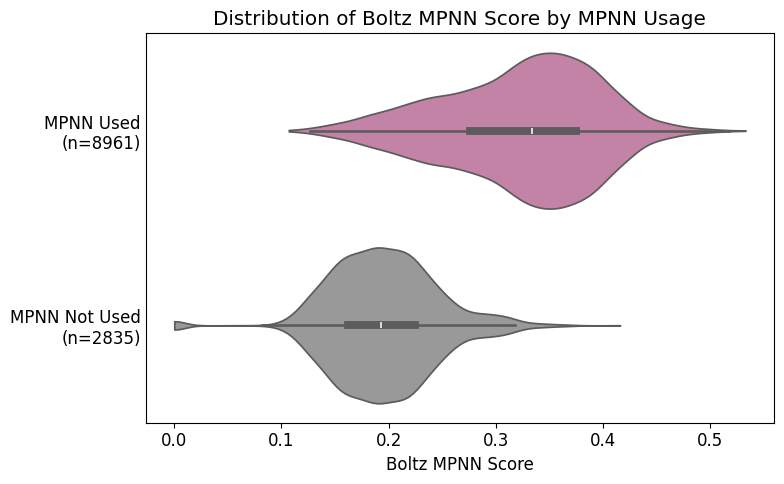

In [18]:
def plot_metric_violin_by_mpnn(feature_name, metric_label=None):
    """
    Create a violin plot comparing a metric between MPNN Used and Not Used.
    
    Parameters
    ----------
    feature_name : str
        Column name in metrics_df to plot
    metric_label : str, optional
        Pretty label for the x-axis. If None, uses feature_name.
    """
    
    if metric_label is None:
        metric_label = feature_name.replace("_", " ").title()
    
    # Get feature values and drop NaNs
    feature_vals = metrics_df[feature_name].dropna()
    
    # Align MPNN status with feature values
    # Note: mpnn_used is in metrics_df from the merge earlier
    plot_df = pd.DataFrame({
        feature_name: feature_vals,
        "mpnn_used": metrics_df.loc[feature_vals.index, "mpnn_used"]
    }).dropna()

    # Map boolean to string labels
    plot_df["mpnn_label"] = plot_df["mpnn_used"].map({True: "MPNN Used", False: "MPNN Not Used"})
    
    # Create violin plot
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.violinplot(
        data=plot_df,
        x=feature_name,
        y="mpnn_label",
        orient="h",
        palette={"MPNN Used": "#CC79A7", "MPNN Not Used": "#999999"},
        ax=ax,
        cut=0
    )
    
    # Add counts to y-axis labels
    counts = plot_df["mpnn_label"].value_counts()
    labels = ["MPNN Used", "MPNN Not Used"]
    y_labels = [f"{label}\n(n={counts.get(label, 0)})" for label in labels]
    
    ax.set_yticklabels(y_labels)
    ax.set_ylabel("")
    ax.set_xlabel(metric_label, fontsize=12)
    ax.tick_params(axis="y", length=0)
    ax.set_title(f"Distribution of {metric_label} by MPNN Usage")
    
    plt.tight_layout()
    plt.show()


# Example usage:
plot_metric_violin_by_mpnn("boltz_autoregwithseq_proteinmpnn", "Boltz MPNN Score")

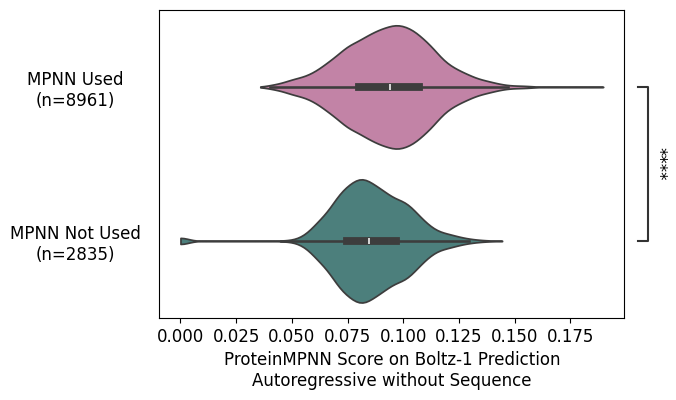

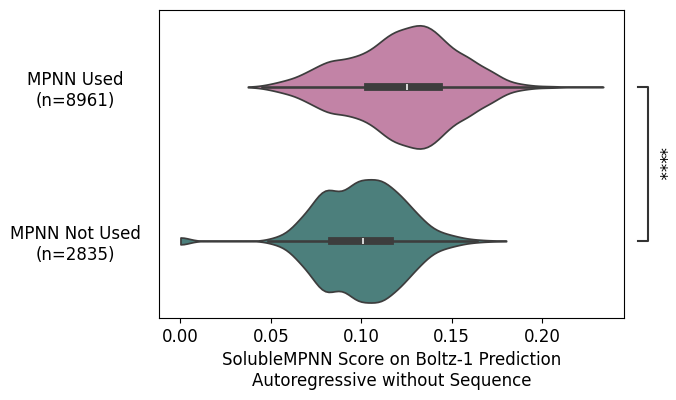

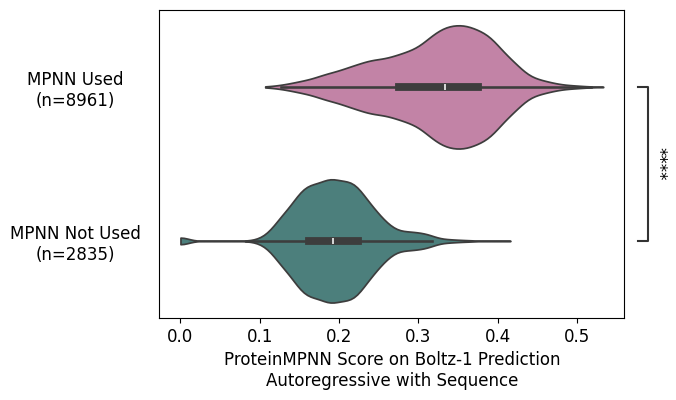

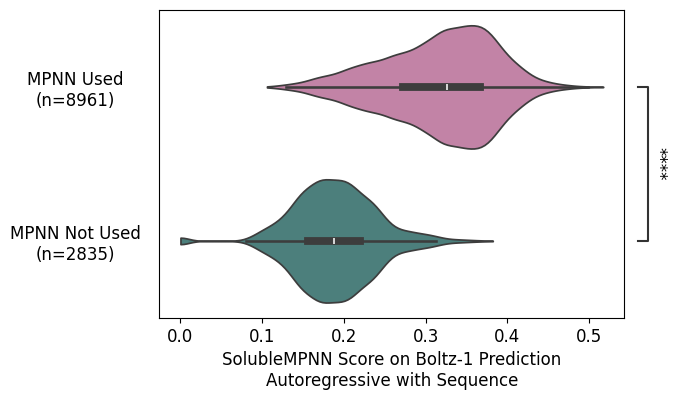

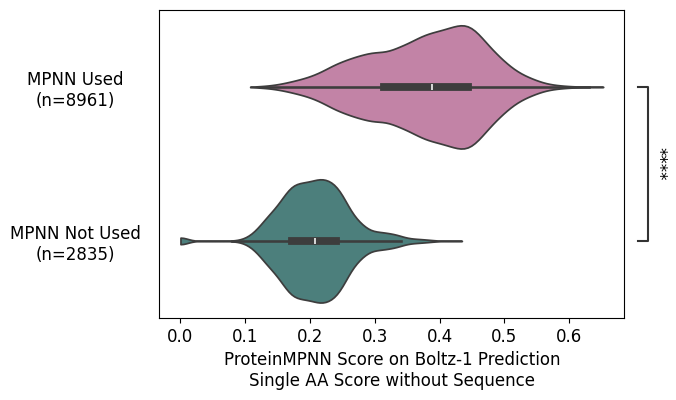

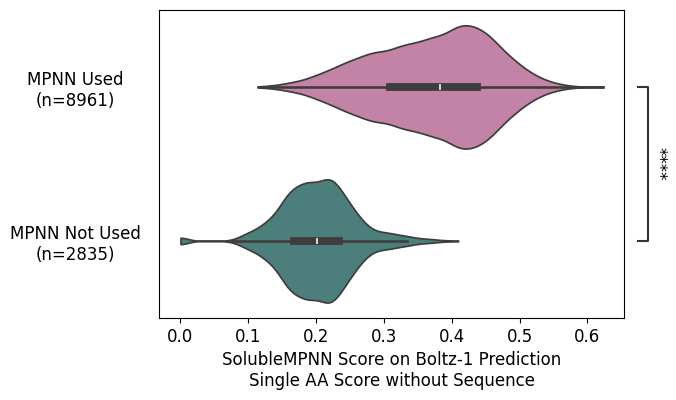

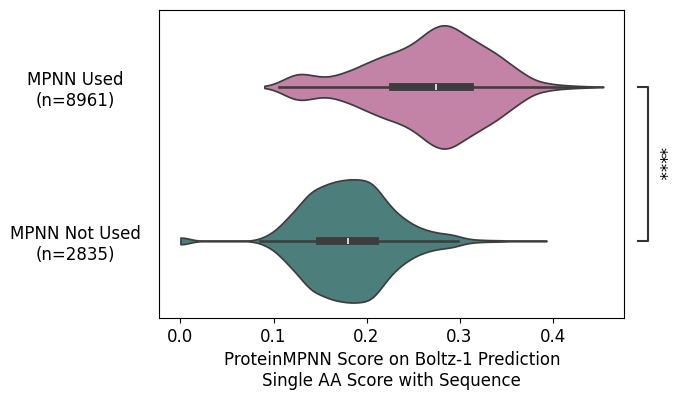

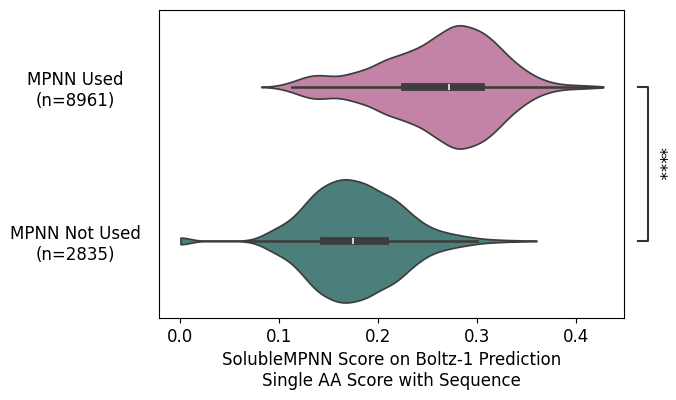

In [26]:
from statannotations.Annotator import Annotator
import os

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
    filter_only_mpnn=False,
):
    """
    Make a violin plot of a feature vs an arbitrary target column.

    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (or metrics_df).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    y_labels_map : dict, optional
        Mapping from target values (as strings) to prettier y labels.
    filter_only_mpnn : bool, optional
        If True, restrict to rows where metrics_df["mpnn_used"] == True, and add
        "MPNN Used" on a new line in each y tick label (before the n count).
    """
    # choose rows (optionally restrict to MPNN designs)
    if filter_only_mpnn:
        mpnn_mask = metrics_df["mpnn_used"] == True
        feature_vals = metrics_df.loc[mpnn_mask, feature].dropna()
        # align target on same index (metrics_df first, then results_df)
        if target_col in metrics_df.columns:
            target_vals = metrics_df.loc[feature_vals.index, target_col]
        else:
            target_vals = results_df.loc[feature_vals.index, target_col]
    else:
        feature_vals = metrics_df[feature].dropna()
        # align target on same index (metrics_df first, then results_df)
        if target_col in metrics_df.columns:
            target_vals = metrics_df.loc[feature_vals.index, target_col]
        else:
            target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # normalize everything to string labels so seaborn + palette + y_labels_map agree
    df["target"] = df["target"].astype(str)
    class_order = [str(c) for c in class_order]

    if isinstance(class_palette, dict):
        class_palette = {str(k): v for k, v in class_palette.items()}

    if y_labels_map is not None:
        y_labels_map = {str(k): v for k, v in y_labels_map.items()}

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    # y tick labels
    if y_labels_map is not None:
        base_labels = [y_labels_map.get(lab, lab) for lab in class_order]
        ax.set_ylabel("")
    else:
        base_labels = class_order
        ax.set_ylabel(target_col)

    if filter_only_mpnn:
        new_labels = [f"{lab}\nMPNN Used\n(n={counts[str_val]})" for lab, str_val in zip(base_labels, class_order)]
    else:
        new_labels = [f"{lab}\n(n={counts[str_val]})" for lab, str_val in zip(base_labels, class_order)]

    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)
    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # statannotations: all pairwise comparisons between classes in class_order
    pairs = []
    for i in range(len(class_order)):
        for j in range(i + 1, len(class_order)):
            pairs.append((class_order[i], class_order[j]))

    annotator = Annotator(
        ax,
        pairs,
        data=df,
        y="target",
        x=feature,
        order=class_order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="outside",
        verbose=0,
    )
    annotator.apply_and_annotate()

    os.makedirs(save_dir, exist_ok=True)
    feature_safe = feature.replace(" ", "_").replace("/", "_")
    target_safe = str(target_col).replace(" ", "_")

    if filter_only_mpnn:
        out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}_only_mpnn.png"
    else:
        out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"

    # xlim at zero
    # if df[feature].min() >= 0:
        # ax.set_xlim(left=0)

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


# Run for requested feature vs MPNN usage (keep your new colors)

features_to_plot = [
    "boltz_autoregwithoutseq_proteinmpnn",
    "boltz_autoregwithoutseq_solublempnn",
    "boltz_autoregwithseq_proteinmpnn",
    "boltz_autoregwithseq_solublempnn",
    "boltz_singleaascorewithoutseq_proteinmpnn",
    "boltz_singleaascorewithoutseq_solublempnn",
    "boltz_singleaascorewithseq_proteinmpnn",
    "boltz_singleaascorewithseq_solublempnn",
]

for feature in features_to_plot:
    if feature not in metrics_df.columns:
        continue

    plot_feature_violin_generic(
        feature=feature,
        target_col="mpnn_used",
        feature_labels_map={
            "boltz_autoregwithseq_proteinmpnn": "ProteinMPNN Score on Boltz-1 Prediction\nAutoregressive with Sequence",
            "boltz_autoregwithseq_solublempnn": "SolubleMPNN Score on Boltz-1 Prediction\nAutoregressive with Sequence",
            "boltz_autoregwithoutseq_proteinmpnn": "ProteinMPNN Score on Boltz-1 Prediction\nAutoregressive without Sequence",
            "boltz_autoregwithoutseq_solublempnn": "SolubleMPNN Score on Boltz-1 Prediction\nAutoregressive without Sequence",
            "boltz_singleaascorewithseq_proteinmpnn": "ProteinMPNN Score on Boltz-1 Prediction\nSingle AA Score with Sequence",
            "boltz_singleaascorewithseq_solublempnn": "SolubleMPNN Score on Boltz-1 Prediction\nSingle AA Score with Sequence",
            "boltz_singleaascorewithoutseq_proteinmpnn": "ProteinMPNN Score on Boltz-1 Prediction\nSingle AA Score without Sequence",
            "boltz_singleaascorewithoutseq_solublempnn": "SolubleMPNN Score on Boltz-1 Prediction\nSingle AA Score without Sequence",
        },
        class_order=[True, False],
        class_palette={True: "#CC79A7", False: "#448783"},
        y_labels_map={True: "MPNN Used", False: "MPNN Not Used"},
        filter_only_mpnn=False,
    )

Plotting boltz_autoregwithseq_proteinmpnn...


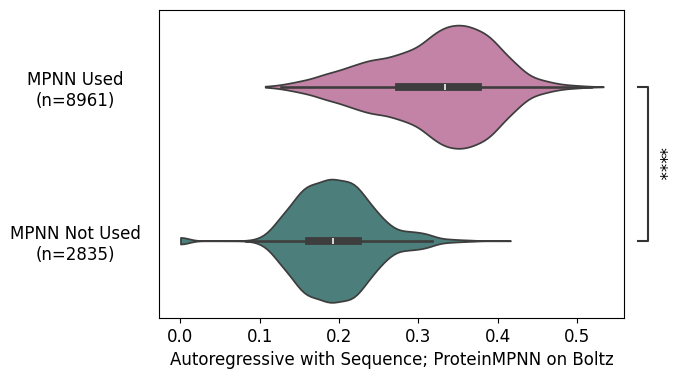

In [20]:
from statannotations.Annotator import Annotator
import os

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
):
    """
    Make a violin plot of a feature vs an arbitrary target column.
    
    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (or metrics_df).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    """
    # values for the feature
    feature_vals = metrics_df[feature].dropna()

    # align target on same index
    # Check metrics_df first, then results_df
    if target_col in metrics_df.columns:
         target_vals = metrics_df.loc[feature_vals.index, target_col]
    else:
         target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # normalize everything to string labels so seaborn + palette + y_labels_map agree
    df["target"] = df["target"].astype(str)
    class_order = [str(c) for c in class_order]

    if isinstance(class_palette, dict):
        class_palette = {str(k): v for k, v in class_palette.items()}

    if y_labels_map is not None:
        y_labels_map = {str(k): v for k, v in y_labels_map.items()}

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    if y_labels_map is not None:
        new_labels = [
            y_labels_map.get(lab, lab) + f"\n(n={counts[lab]})"
            for lab in class_order
        ]
        ax.set_ylabel("")
    else:
        new_labels = [f"{lab}\n(n={counts[lab]})" for lab in class_order]
        ax.set_ylabel(target_col)

    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # statannotations: all pairwise comparisons between classes in class_order
    pairs = []
    for i in range(len(class_order)):
        for j in range(i + 1, len(class_order)):
            pairs.append((class_order[i], class_order[j]))

    try:
        annotator = Annotator(
            ax,
            pairs,
            data=df,
            y="target",
            x=feature,
            order=class_order,
            orient="h",
        )
        annotator.configure(
            test="Mann-Whitney",
            text_format="star",
            loc="outside",
            verbose=0,
        )
        annotator.apply_and_annotate()
    except Exception as e:
        print(f"Could not annotate stats: {e}")

    feature_safe = feature.replace(" ", "_").replace("/", "_")
    target_safe = str(target_col).replace(" ", "_")
    os.makedirs(save_dir, exist_ok=True)
    out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# Run for requested features vs MPNN Usage
features_to_plot = [
    "boltz_autoregwithseq_proteinmpnn"
]

for feature in features_to_plot:
    if feature not in metrics_df.columns:
        continue
        
    print(f"Plotting {feature}...")
    plot_feature_violin_generic(
        feature=feature,
        target_col="mpnn_used",
        feature_labels_map={
            "boltz_autoregwithseq_proteinmpnn": "Autoregressive with Sequence; ProteinMPNN on Boltz"
        },
        class_order=[True, False],
        class_palette={True: "#CC79A7", False: "#448783"}, # Purple/Grey palette for MPNN
        y_labels_map={True: "MPNN Used", False: "MPNN Not Used"},
    )

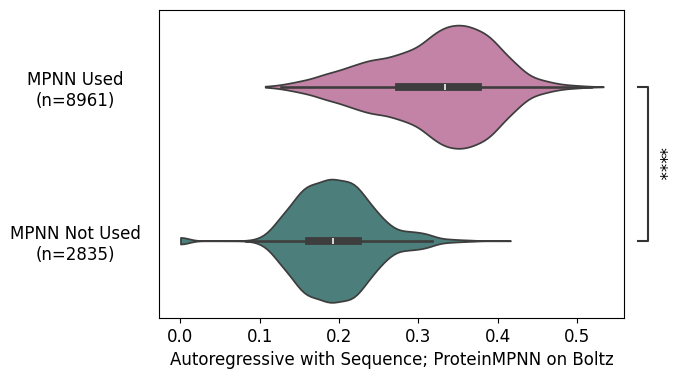

In [21]:
def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
    filter_only_mpnn=False,
):
    """
    Make a violin plot of a feature vs an arbitrary target column.

    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (or metrics_df).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    y_labels_map : dict, optional
        Mapping from target values (as strings) to prettier y labels.
    filter_only_mpnn : bool, optional
        If True, restrict to rows where metrics_df["mpnn_used"] == True, and add
        "MPNN Used" on a new line in each y tick label (before the n count).
    """
    # choose rows (optionally restrict to MPNN designs)
    if filter_only_mpnn:
        mpnn_mask = metrics_df["mpnn_used"] == True
        feature_vals = metrics_df.loc[mpnn_mask, feature].dropna()
        # align target on same index (metrics_df first, then results_df)
        if target_col in metrics_df.columns:
            target_vals = metrics_df.loc[feature_vals.index, target_col]
        else:
            target_vals = results_df.loc[feature_vals.index, target_col]
    else:
        feature_vals = metrics_df[feature].dropna()
        # align target on same index (metrics_df first, then results_df)
        if target_col in metrics_df.columns:
            target_vals = metrics_df.loc[feature_vals.index, target_col]
        else:
            target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # normalize everything to string labels so seaborn + palette + y_labels_map agree
    df["target"] = df["target"].astype(str)
    class_order = [str(c) for c in class_order]

    if isinstance(class_palette, dict):
        class_palette = {str(k): v for k, v in class_palette.items()}

    if y_labels_map is not None:
        y_labels_map = {str(k): v for k, v in y_labels_map.items()}

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    # y tick labels
    if y_labels_map is not None:
        base_labels = [y_labels_map.get(lab, lab) for lab in class_order]
        ax.set_ylabel("")
    else:
        base_labels = class_order
        ax.set_ylabel(target_col)

    if filter_only_mpnn:
        new_labels = [f"{lab}\nMPNN Used\n(n={counts[str_val]})" for lab, str_val in zip(base_labels, class_order)]
    else:
        new_labels = [f"{lab}\n(n={counts[str_val]})" for lab, str_val in zip(base_labels, class_order)]

    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)
    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # statannotations: all pairwise comparisons between classes in class_order
    pairs = []
    for i in range(len(class_order)):
        for j in range(i + 1, len(class_order)):
            pairs.append((class_order[i], class_order[j]))

    annotator = Annotator(
        ax,
        pairs,
        data=df,
        y="target",
        x=feature,
        order=class_order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="outside",
        verbose=0,
    )
    annotator.apply_and_annotate()

    os.makedirs(save_dir, exist_ok=True)
    feature_safe = feature.replace(" ", "_").replace("/", "_")
    target_safe = str(target_col).replace(" ", "_")

    if filter_only_mpnn:
        out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}_only_mpnn.png"
    else:
        out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"

    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


# Run for requested feature vs MPNN usage (keep your new colors)

features_to_plot = [
    "boltz_autoregwithseq_proteinmpnn",
]

for feature in features_to_plot:
    if feature not in metrics_df.columns:
        continue

    plot_feature_violin_generic(
        feature=feature,
        target_col="mpnn_used",
        feature_labels_map={
            "boltz_autoregwithseq_proteinmpnn": "Autoregressive with Sequence; ProteinMPNN on Boltz",
        },
        class_order=[True, False],
        class_palette={True: "#CC79A7", False: "#448783"},
        y_labels_map={True: "MPNN Used", False: "MPNN Not Used"},
        filter_only_mpnn=False,
    )

## Stacked Bar Plot Template

Template for showing proportion of detected/not detected across a categorical or binned metric.

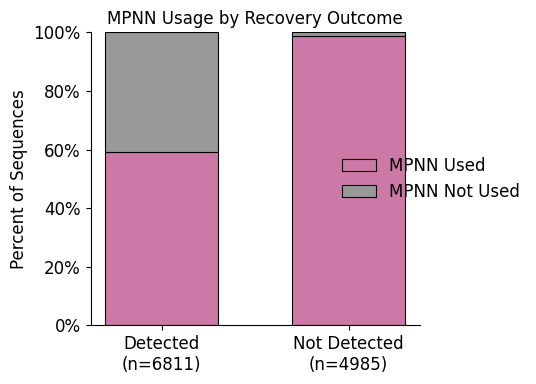

In [22]:
# Inverted plot: Recovery Status (X) colored by MPNN Usage
def plot_mpnn_usage_by_recovery():
    """
    Plot the proportion of sequences using MPNN within 'Detected' vs 'Not Detected' groups.
    X-axis: Recovery Status (Detected / Not Detected)
    Colors: MPNN Usage (Used / Not Used)
    """
    # Prepare data
    plot_df = pd.DataFrame({
        "Status": results_df["detected_label"],
        "MPNN": metrics_df["mpnn_used"].fillna(False).map({True: "MPNN Used", False: "MPNN Not Used"})
    })

    # Calculate proportions
    prop = pd.crosstab(plot_df["Status"], plot_df["MPNN"], normalize="index") * 100
    
    # Ensure columns exist
    for col in ["MPNN Used", "MPNN Not Used"]:
        if col not in prop.columns:
            prop[col] = 0
            
    categories = ["Detected", "Not Detected"]
    counts = plot_df["Status"].value_counts()
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(categories))
    width = 0.6
    
    # Bottom: MPNN Used (Purple)
    ax.bar(x, prop.loc[categories, "MPNN Used"], width, label="MPNN Used", 
           color="#CC79A7", edgecolor="black", linewidth=0.8)
           
    # Top: MPNN Not Used (Grey)
    ax.bar(x, prop.loc[categories, "MPNN Not Used"], width, 
           bottom=prop.loc[categories, "MPNN Used"], label="MPNN Not Used", 
           color="#999999", edgecolor="black", linewidth=0.8)
           
    x_labels = [f"{cat}\n(n={counts[cat]})" for cat in categories]
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percent of Sequences", fontsize=12)
    ax.yaxis.set_major_formatter(PercentFormatter())
    
    ax.legend(frameon=False, loc="center right", bbox_to_anchor=(1.35, 0.5))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title("MPNN Usage by Recovery Outcome", fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_mpnn_usage_by_recovery()

## Joint KDE Plot Template

Template for comparing two continuous metrics with a joint distribution plot.

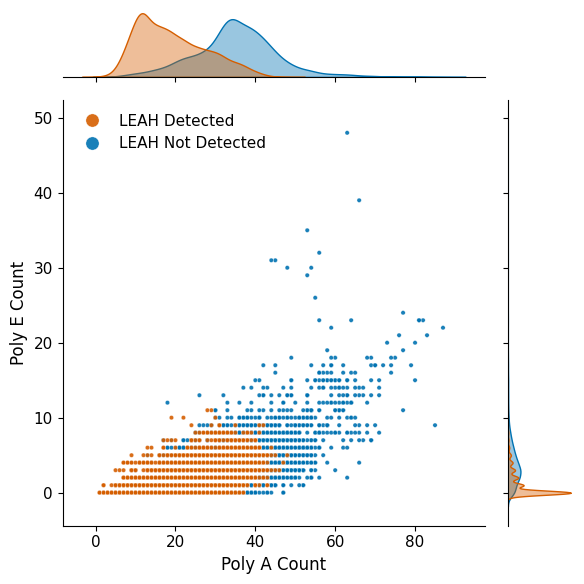

In [23]:
def plot_joint_metrics(feat_x, feat_y, x_label=None, y_label=None):
    """
    Create a joint distribution plot comparing two metrics between Detected and Not Detected.
    Shows scatter plot with marginal distributions.
    
    Parameters
    ----------
    feat_x : str
        Column name in metrics_df for x-axis
    feat_y : str
        Column name in metrics_df for y-axis
    x_label : str, optional
        Pretty label for x-axis. If None, uses feature name.
    y_label : str, optional
        Pretty label for y-axis. If None, uses feature name.
    """
    
    if x_label is None:
        x_label = feat_x.replace("_", " ").title()
    if y_label is None:
        y_label = feat_y.replace("_", " ").title()
    
    # Build plotting dataframe
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    
    # Attach detection labels
    plot_df["detected"] = results_df.loc[plot_df.index, "detected_label"]
    plot_df = plot_df.dropna(subset=["detected"])
    
    # Sort so "Not Detected" is plotted first (underneath)
    plot_df = plot_df.sort_values("detected", ascending=False)
    
    # Create joint plot
    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="detected",
        hue_order=["Detected", "Not Detected"],
        palette={"Detected": "#D55E00", "Not Detected": "#0072B2"},
        kind="scatter",
        s=10,
        alpha=0.9,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4)
    )
    
    # Format labels
    g.ax_joint.set_xlabel(x_label, fontsize=12)
    g.ax_joint.set_ylabel(y_label, fontsize=12)
    g.ax_joint.tick_params(axis="x", labelsize=11)
    g.ax_joint.tick_params(axis="y", labelsize=11)
    
    # Adjust legend
    handles = g.ax_joint.get_legend().legend_handles
    g.ax_joint.legend(
        handles,
        ["LEAH Detected", "LEAH Not Detected"],
        markerscale=3,
        fontsize=11,
        title="",
        frameon=False,
        loc="best"
    )
    
    plt.tight_layout()
    plt.show()


# Example usage:
plot_joint_metrics("poly_A_count", "poly_E_count", 
                   "Poly A Count", "Poly E Count")
# plot_joint_metrics("gravy_score", "dna_gc_content",
#                    "GRAVY Score", "DNA GC Content")